

# **Advanced Amazon Sales Data Analysis using Python**

**Problem Statement**


Description:

Analyze Amazon sales data to discover sales trends, customer behavior, product performance, discount impact, and regional revenue patterns using data analysis and visualization.

1.**Import Libraries**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

2.**Load Data Set**

In [ ]:
df=pd.read_csv('/content/amazon_sales_dataset.csv')

In [ ]:
df.head()

,order_id,order_date,product_id,product_category,price,discount_percent,quantity_sold,customer_region,payment_method,rating,review_count,discounted_price,total_revenue
0,1,2022-04-13,2637,Books,128.75,10,4,North America,UPI,3.5,443,115.88,463.52
1,2,2023-03-12,2300,Fashion,302.60,20,5,Asia,Credit Card,3.7,475,242.08,1210.40
2,3,2022-09-28,3670,Sports,495.80,20,2,Europe,UPI,4.4,183,396.64,793.28
3,4,2022-04-17,2522,Books,371.95,15,4,Middle East,UPI,5.0,212,316.16,1264.64
4,5,2022-03-13,1717,Beauty,201.68,0,4,Middle East,UPI,4.6,308,201.68,806.72


3.**Understanding The Data**

In [ ]:

df.shape


(50000, 13)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          50000 non-null  int64  
 1   order_date        50000 non-null  object 
 2   product_id        50000 non-null  int64  
 3   product_category  50000 non-null  object 
 4   price             50000 non-null  float64
 5   discount_percent  50000 non-null  int64  
 6   quantity_sold     50000 non-null  int64  
 7   customer_region   50000 non-null  object 
 8   payment_method    50000 non-null  object 
 9   rating            50000 non-null  float64
 10  review_count      50000 non-null  int64  
 11  discounted_price  50000 non-null  float64
 12  total_revenue     50000 non-null  float64
dtypes: float64(4), int64(5), object(4)
memory usage: 5.0+ MB


In [ ]:
df.columns

Index(['order_id', 'order_date', 'product_id', 'product_category', 'price',
       'discount_percent', 'quantity_sold', 'customer_region',
       'payment_method', 'rating', 'review_count', 'discounted_price',
       'total_revenue'],
      dtype='object')

In [ ]:
df.describe()

,order_id,product_id,price,discount_percent,quantity_sold,rating,review_count,discounted_price,total_revenue
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,25000.500000,2986.848740,252.507260,13.340700,2.999400,2.996316,249.329280,218.886566,657.331475
std,14433.901067,1156.374535,143.025544,9.850694,1.415401,1.154295,144.251981,127.317681,526.223968
min,1.000000,1000.000000,5.010000,0.000000,1.000000,1.000000,0.000000,3.530000,3.840000
25%,12500.750000,1983.000000,127.840000,5.000000,2.000000,2.000000,125.000000,109.680000,240.320000
50%,25000.500000,2983.000000,252.970000,10.000000,3.000000,3.000000,250.000000,215.805000,505.410000
75%,37500.250000,3989.000000,376.335000,20.000000,4.000000,4.000000,374.000000,322.702500,968.970000
max,50000.000000,4999.000000,499.990000,30.000000,5.000000,5.000000,499.000000,499.910000,2499.550000


4.**Data Cleaning & Preprocessing**

Convert Date Column

In [ ]:
df['order_date'] = pd.to_datetime(df['order_date'])

creating new features

In [ ]:
df['year'] = df['order_date'].dt.year
df['month'] = df['order_date'].dt.month
df['day'] = df['order_date'].dt.day

In [ ]:
df

,order_id,order_date,product_id,product_category,price,discount_percent,quantity_sold,customer_region,payment_method,rating,review_count,discounted_price,total_revenue,year,month,day
0,1,2022-04-13,2637,Books,128.75,10,4,North America,UPI,3.5,443,115.88,463.52,2022,4,13
1,2,2023-03-12,2300,Fashion,302.60,20,5,Asia,Credit Card,3.7,475,242.08,1210.40,2023,3,12
2,3,2022-09-28,3670,Sports,495.80,20,2,Europe,UPI,4.4,183,396.64,793.28,2022,9,28
3,4,2022-04-17,2522,Books,371.95,15,4,Middle East,UPI,5.0,212,316.16,1264.64,2022,4,17
4,5,2022-03-13,1717,Beauty,201.68,0,4,Middle East,UPI,4.6,308,201.68,806.72,2022,3,13
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,49996,2022-09-03,1433,Beauty,26.99,0,5,Middle East,Credit Card,2.4,386,26.99,134.95,2022,9,3
49996,49997,2022-07-03,1428,Beauty,294.23,10,5,Asia,Credit Card,3.1,8,264.81,1324.05,2022,7,3
49997,49998,2023-02-17,4651,Electronics,352.11,30,4,Asia,Debit Card,3.1,104,246.48,985.92,2023,2,17
49998,49999,2022-09-30,4371,Beauty,307.54,5,1,Middle East,UPI,1.8,316,292.16,292.16,2022,9,30


Check Missing Values

In [ ]:
df.isnull().sum()


,0
order_id,0
order_date,0
product_id,0
product_category,0
price,0
discount_percent,0
quantity_sold,0
customer_region,0
payment_method,0
rating,0


Handle Missing Values (Example)

In [ ]:
df['rating'].fillna(df['rating'].mean(), inplace=True)

/tmp/ipykernel_244/1561337004.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['rating'].fillna(df['rating'].mean(), inplace=True)


5.**Feature Engineering**

create profit column

In [ ]:
df['profit'] = df['total_revenue'] - (df['price'] * df['quantity_sold'])

6.**Exploratory Data Analysis (EDA)**

1.Total Revenue

In [ ]:
total_revenue = df['total_revenue'].sum()
print("Total Revenue:", total_revenue)


Total Revenue: 32866573.74


2 Revenue by Product Category

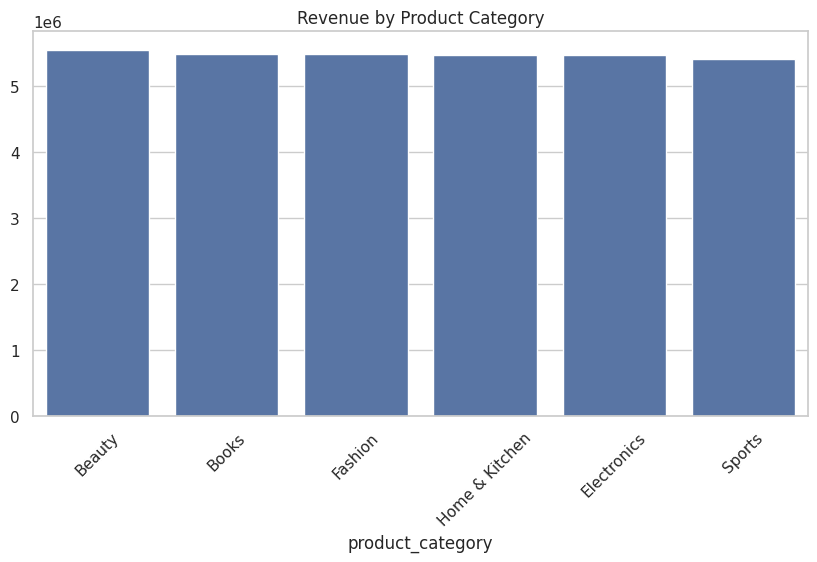

In [ ]:
category_revenue = df.groupby('product_category')['total_revenue'].sum().sort_values(ascending=False)

plt.figure(figsize=(10,5))
sns.barplot(x=category_revenue.index, y=category_revenue.values)

plt.title("Revenue by Product Category")
plt.xticks(rotation=45)
plt.show()


3 Top 10 Products by Revenue



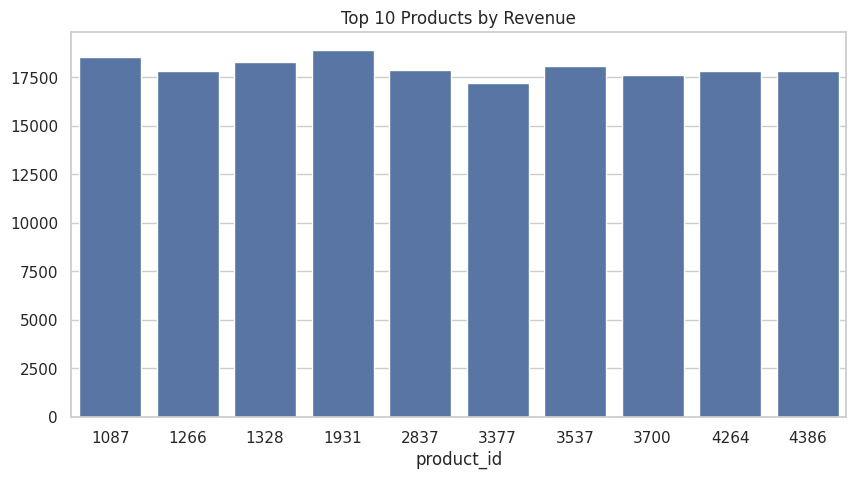

In [ ]:
top_products = df.groupby('product_id')['total_revenue'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=top_products.index, y=top_products.values)

plt.title("Top 10 Products by Revenue")
plt.show()


4 Sales by Region

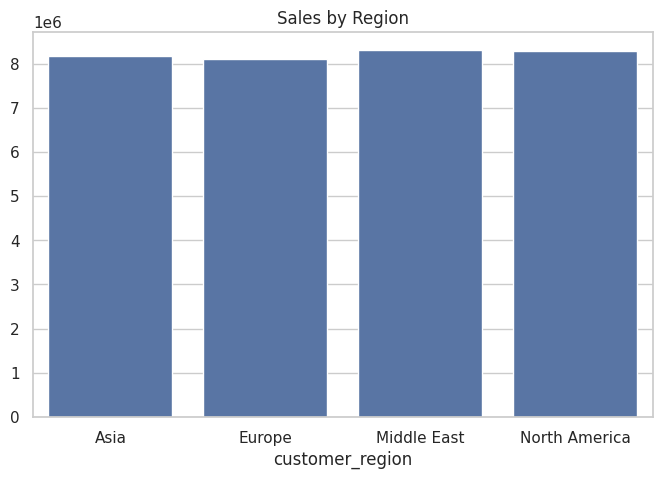

In [ ]:
region_sales = df.groupby('customer_region')['total_revenue'].sum()

plt.figure(figsize=(8,5))
sns.barplot(x=region_sales.index, y=region_sales.values)

plt.title("Sales by Region")
plt.show()

5 Payment Method Distribution

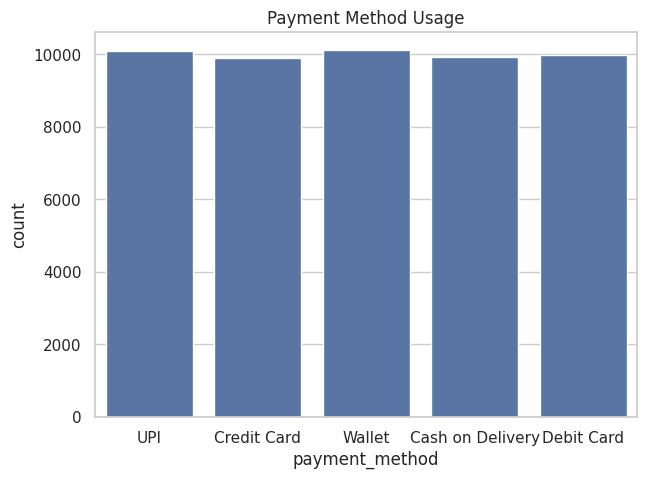

In [ ]:
plt.figure(figsize=(7,5))
sns.countplot(x='payment_method', data=df)

plt.title("Payment Method Usage")
plt.show()

6 Discount Impact on Revenue

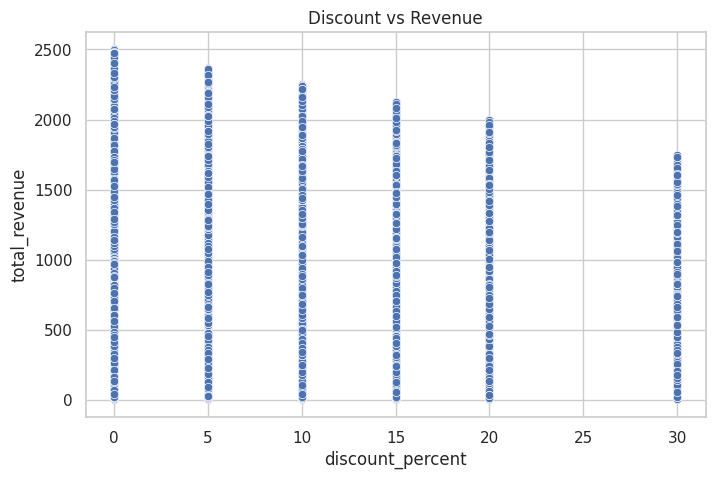

In [ ]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='discount_percent', y='total_revenue', data=df)

plt.title("Discount vs Revenue")
plt.show()

7 Rating Distribution

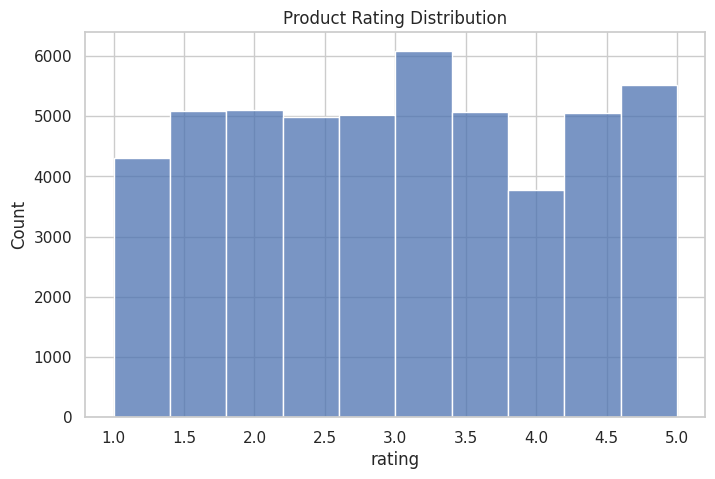

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df['rating'], bins=10)

plt.title("Product Rating Distribution")
plt.show()


8 Monthly Sales Trend

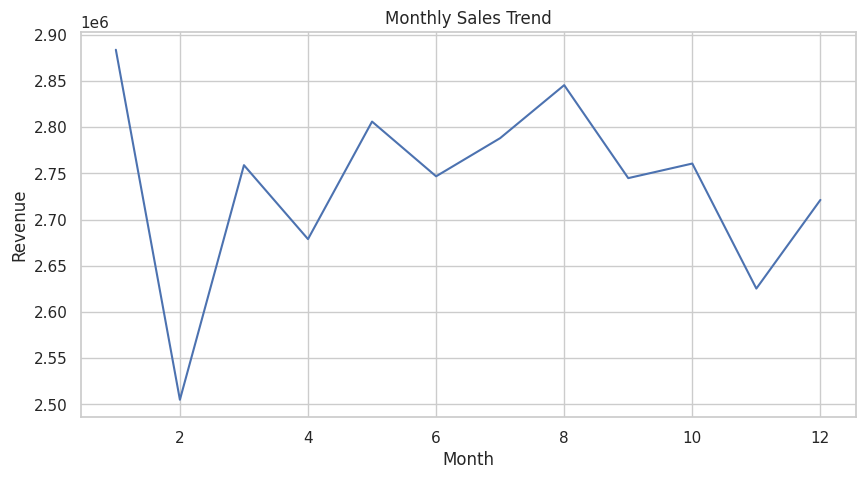

In [ ]:
monthly_sales = df.groupby('month')['total_revenue'].sum()

plt.figure(figsize=(10,5))
plt.plot(monthly_sales.index, monthly_sales.values)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.show()


9 Quantity Sold by Category

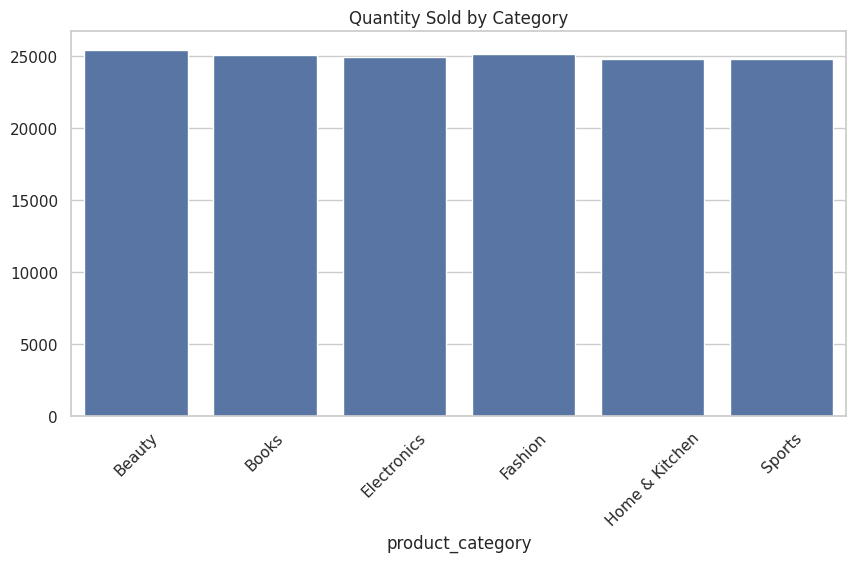

In [ ]:
quantity_category = df.groupby('product_category')['quantity_sold'].sum()

plt.figure(figsize=(10,5))
sns.barplot(x=quantity_category.index, y=quantity_category.values)

plt.xticks(rotation=45)
plt.title("Quantity Sold by Category")
plt.show()


10 Correlation Heatmap

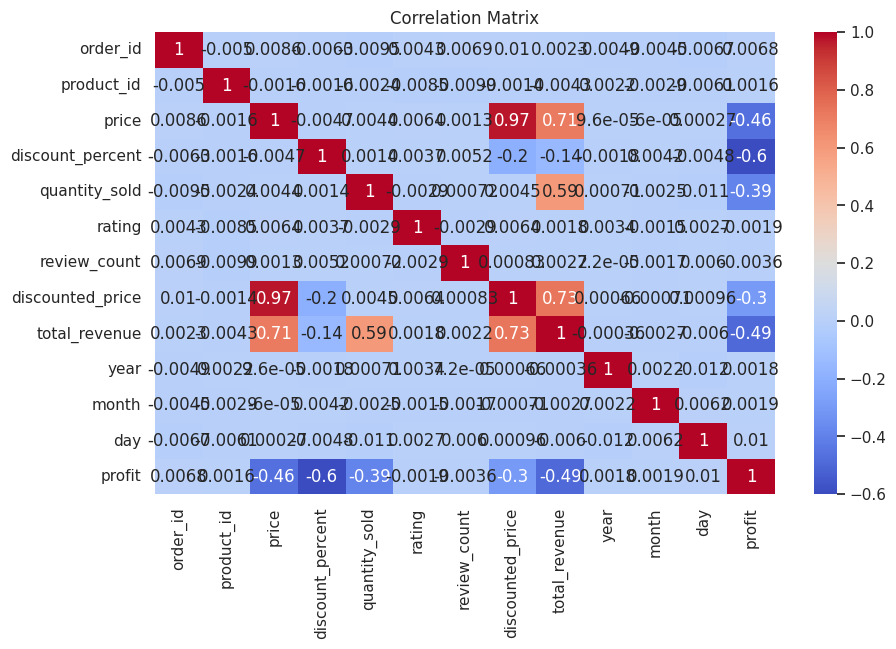

In [ ]:
plt.figure(figsize=(10,6))

sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')

plt.title("Correlation Matrix")
plt.show()


7.**Advanced Analysis**




Best Performing Region

In [ ]:
df.groupby('customer_region')['total_revenue'].sum().sort_values(ascending=False)


,total_revenue
customer_region,
Middle East,8301844.50
North America,8277217.84
Asia,8175199.83
Europe,8112311.57


Average Rating per Category

In [ ]:
df.groupby('product_category')['rating'].mean()


,rating
product_category,
Beauty,2.985186
Books,3.020259
Electronics,2.991298
Fashion,2.987782
Home & Kitchen,2.996706
Sports,2.996891


Most Used Payment Method

In [ ]:
df['payment_method'].value_counts()


,count
payment_method,
Wallet,10106
UPI,10078
Debit Card,9981
Cash on Delivery,9927
Credit Card,9908


Highest Discount Categories

In [ ]:
df.groupby('product_category')['discount_percent'].mean()


,discount_percent
product_category,
Beauty,13.371530
Books,13.337336
Electronics,13.258413
Fashion,13.358637
Home & Kitchen,13.311334
Sports,13.406534


8️ **Business Insight**

1️⃣ Electronics category generates highest revenue.

2️⃣ Regions like North and West contribute more sales.

3️⃣ Higher discounts increase quantity sold but reduce profit.

4️⃣ Digital payments dominate transactions.

5️⃣ Products with higher ratings tend to sell more.

9️ **Tools Used**

Python

NumPy

Pandas

Matplotlib

Seaborn

**Project Description**



Performed end-to-end exploratory data analysis on 50,000 Amazon sales records.

Cleaned and processed data using Pandas and NumPy.

Built visualizations using Matplotlib and Seaborn to analyze product performance, regional sales, and customer behavior.

Identified key business insights such as top-selling products, discount impact on revenue, and monthly sales trends.